Aluno: Afonso Henrique Guimarães de Oliveira


# CAPÍTULO 1: APRENDIZADO SUPERVISIONADO

Modelo de Machine Learning de crédito tendo em vista o histórico dos últimos clientes do banco. O objetivo é classificar um cliente em poor (provável mau pagador), standard (médio) ou good (provável bom pagador).

## Contexto

Você trabalha como cientista de dados em uma empresa financeira global. Ao longo dos anos, a empresa coletou informações bancárias básicas e reuniu uma grande quantidade de dados relacionados a crédito. A gerência deseja construir um sistema inteligente para segmentar as pessoas em faixas de pontuação de crédito, reduzindo assim o trabalho manual. (kaggle)

### Features Disponíveis

- ID:                                       Representa uma identificação única de um registro
- Customer_ID:                              Representa uma identificação única de uma pessoa
- Month:                                    Representa o mês do ano
- Name:                                     Representa o nome de uma pessoa
- Age:                                      Representa a idade da pessoa
- SSN:                                      Representa o número de seguridade social de uma pessoa
- Occupation:                               Representa a ocupação da pessoa
- Annual_Income:                            Representa a renda anual da pessoa
- Monthly_Inhand_Salary:                    Representa o salário base mensal de uma pessoa
- Num_Bank_Accounts:                        Representa o número de contas bancárias que uma pessoa possui
- Num_Credit_Card:                          Representa o número de outros cartões de crédito que uma pessoa possui
- Interest_Rate:                            Representa a taxa de juros no cartão de crédito
- Num_of_Loan:                              Representa o número de empréstimos tomados no banco
- Type_of_Loan:                             Representa os tipos de empréstimo tomados por uma pessoa
- Delay_from_due_date:                      Representa o número médio de dias de atraso em relação à data de vencimento
- Num_of_Delayed_Payment:                   Representa o número médio de pagamentos atrasados por uma pessoa
- Changed_Credit_Limit:                     Representa a variação percentual no limite do cartão de crédito
- Num_Credit_Inquiries:                     Representa o número de consultas ao cartão de crédito
- Credit_Mix:                               Representa a classificação da combinação de créditos
- Outstanding_Debt:                         Representa a dívida restante a ser paga (em USD)
- Credit_Utilization_Ratio:                 Representa a taxa de utilização do cartão de crédito
- Credit_History_Age:                       Representa a idade do histórico de crédito da pessoa
- Payment_of_Min_Amount:                    Representa se apenas o valor mínimo foi pago pela pessoa
- Total_EMI_per_month:                      Representa os pagamentos mensais de parcelas (em USD)
- Amount_invested_monthly:                  Representa o valor mensal investido pelo cliente (em USD)
- Payment_Behaviour:                        Representa o comportamento de pagamento do cliente (em USD)
- Monthly_Balance:                          Representa o saldo mensal do cliente (em USD)


Fonte: Kaggle

### Target

- Credit_Score:                             Representa a classificação do cliente como mal, médio ou bom pagador (Alvo)

## Carregamento dos dados

In [115]:
!pip install pandas

In [116]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [117]:
# from google.colab import drive
# drive.mount('/content/drive')

In [118]:
data = pd.read_csv(r"./data/train.csv")
# data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data/train.csv")


/tmp/ipykernel_24192/186379594.py:1: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"./data/train.csv")


Apenas a base de treino foi carregada, pois a de teste não possui a coluna Credit_Score, o que indica que se trata de uma base para avaliar um modelo já completo (treinado e testado), pelo Kaggle ou pelos autores do desafio.

## Análise Exploratória dos Dados

In [119]:
data

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,7,11.5,3.0,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",18,7,11.5,3.0,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",27,6,11.5,3.0,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",20,NaN,11.5,3.0,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [120]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  str    
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  str    
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

Há dados nulos nas colunas:
- Name,
- Monthly_Inhand_Salary,
- Type_of_Loan,
- Num_of_Delayed_Payment,
- Num_Credit_Inquiries,
- Credit_History_Age,
- Amount_invested_monthly,              
- Monthly_Balance

No entando a coluna name não tem valor para o modelo, assim como ID, SSN e Customer_ID.

Há também colunas que deveriam ser numéricas, mas estão como object:
- Age,
- Annual_Income,
- Num_of_Loan,
- Num_of_Delayed_Paymen,
- Changed_Credit_Limit,                  
- Outstanding_Debt,
- Credit_History_Age,
- Amount_invested_monthly,
- Monthly_Balance        

Isso evidencia a necessidade de limpeza dos dados. No entanto, nenhum tratamento precisa ser feita em Age, pois essa coluna deve ser desprezada a fim de evitar que o modelo inclua qualquer tipo de preconceito baseado na faixa etária do cliente.

Observando os dados contidos no dataframe, para um mesmo cliente em uma mesma feature há dados consistentes em uma linha e inconsistentes em outra. Por exemplo, em Annual_Income há dados para um mesmo cliente com um underline ao final do número, enquanto de as demais linhas possuem valores limpos. Faz sentido então usar uma estratégia de substitituição de valores considerando os valores associados ao mesmo cliente.

In [121]:
data.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [122]:
data.groupby("Customer_ID").agg("count")

,ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
Customer_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
CUS_0x1000,8,8,7,8,8,8,8,7,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
CUS_0x1009,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,7,8,8,8,8,8,8
CUS_0x100b,8,8,7,8,8,8,8,7,8,8,8,8,0,8,8,8,8,8,8,8,7,8,8,7,8,8,8
CUS_0x1011,8,8,8,8,8,8,8,7,8,8,8,8,8,8,6,8,8,8,8,8,8,8,8,8,8,8,8
CUS_0x1013,8,8,8,8,8,8,8,5,8,8,8,8,8,8,7,8,8,8,8,8,7,8,8,8,8,8,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CUS_0xff3,8,8,6,8,8,8,8,7,8,8,8,8,8,8,8,8,8,8,8,8,7,8,8,8,8,8,8
CUS_0xff4,8,8,7,8,8,8,8,7,8,8,8,8,8,8,8,8,6,8,8,8,7,8,8,8,8,8,8
CUS_0xff6,8,8,8,8,8,8,8,8,8,8,8,8,8,8,7,8,7,8,8,8,8,8,8,7,8,7,8


Cabe mais uma ressalva quanto ao ID do cliente, pois há 8 registros por cliente. Apesar da inutilidade da coluna para o modelo, esta pode ser útil para agrupar dados e produção de novas features.

In [123]:
!pip install matplotlib

Credit_Score
Standard    0.53174
Poor        0.28998
Good        0.17828
Name: proportion, dtype: float64


<Axes: >

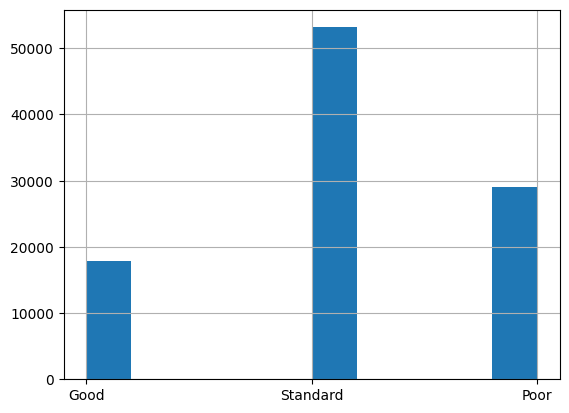

In [124]:
print(data['Credit_Score'].value_counts(normalize=True))
data['Credit_Score'].hist()

O histograma e o value_counts do target revelam que há um desbalanceamento dos dados, de modo que mais da metade dos clientes possuem a classificação de pagador médio, enquanto que menos de 20% são prováveis bons pagadores. Isso revela a importancia de usar estratificação na divisão de treino e teste. Pode-se também realizar o balanceamento dos dados com algumas das ferramentas disponibilizadas pelo python, especialmente o sklearn.

## Agrupamento dos Dados

Minha primeira tentativa foi treinar modelos com 80.000 linhas de treino e 20.000 de testes. No entanto, o SVM e o Adabosting estavam levando muito tempo para concluir. Não deixei esssa tentativa no arquivo pois as células levariam bastante tempo pra concluir. Aliado a isso, há 8 linhas por cliente e o objetivo do modelo é classificar os clientes como potenciais bom, médio ou mal pagadores. Então decidi agrupar os dados por cliente. Percebi que seria necessário fazer isso antes da divisão em treino e teste, pois quero evitar que existam dados de um mesmo cliente no treino e no teste, o que poderia implicar num vazamento de dados. Isso também gerou a necessidade de adiantar o pré-processamento para antes do split.

Via de regra, colunas numéricas serão agrupadas pela média e colunas categóricas serão agrupadas pela moda. Para isso crio as duas funções abaixo para realizar o agrupamento. No entanto não as aplico ainda pois há colunas que deveriam ser numéricas e não o são.

In [125]:
!pip install numpy

In [126]:
import numpy as np
def Agrupar_Dados(df: pd.DataFrame):

    #compressão de dicionário para gerar uma estrutura chave valor cuja chave é o nome da coluna e o valor é "mean", indicando para o agg que quero agrupar a coluna pela média
    agg_dict_num = {
        col: "mean" 
            for col in df.select_dtypes(include=np.number).columns.tolist()
                  if col != 'Customer_ID'
    }

    df_group_num = df.groupby("Customer_ID").agg(agg_dict_num).reset_index()


    agg_dict_cat = {
        col: lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan 
            for col in df.select_dtypes(exclude=np.number).columns.tolist()
                if col != 'Customer_ID'
    }

    df_group_cat = df.groupby("Customer_ID").agg(agg_dict_cat).reset_index()

    df_group = pd.merge(left=df_group_num, right=df_group_cat, how='inner', on='Customer_ID')

    return df_group

## Pré-processamento de Dados

Algumas colunas do dataset original não possuem valor real para o modelo, como ID, Nome e identificador do Seguro Social. Então crio uma uma função que poderá ser reutilizada para  qualquer dos dataframes deste problema, mesmo já divididos em treino e test. A coluna Age é excluída para evitar a introdução de qualquer pre-conceito no modelo.

### Funções de Pré-Processamento


In [127]:
def Drop_Columns (df: pd.DataFrame, columns_drop:list = ['ID', 'Name', 'Age', 'SSN']):
    return df.drop(columns=columns_drop, errors="ignore")


Criei uma função para transformar a coluna Credit_History_Age em float já que seus dados indicam um período em anos na forma de string. Ex.: "17 Years and 1 Months	"

In [128]:
import re
import numpy as np
def Convert_String_To_Time(value):
    match = False
    if not isinstance(value, str):
        return np.nan

    match = re.search(r'(\d+) Years? and (\d+) Months?', value)

    if not match:
        return np.nan

    y, m = match.groups()

    return int(y) + int(m)/12

Algumas colunas que deveriam ser float não o são por causa de um underline após o valor correto. A função abaixo serve para remover.


In [129]:
def Convert_String_To_Float(value):
    if isinstance(value, float): return value

    try:
        return round(float(value.replace('_', '')),2)
    except Exception:
        return np.nan



A Função a seguir é semelhante à primeira, mas aplica-se a coluna Changed_Credit_Limit, em que há alguns dados apenas com um traço, o que pode indicar que não houve mudança no limite de crédito. Então por padrão substitui por zero ou chama a função anterior.

In [130]:
def Convert_String_To_Float_Default_Zero(value):
    if isinstance(value, float): return value

    try:
        if value == '-': return 0
        return Convert_String_To_Float(value)
    except Exception:
        return np.nan

A próxima função aplica as funções anteriores às colunas que deveriam ser numéricas.

In [131]:
def Clear_Data_Should_number(df: pd.DataFrame):

  columns_number = [
      'Annual_Income',
      'Num_of_Loan',
      'Num_of_Delayed_Payment',
      'Outstanding_Debt',
      'Amount_invested_monthly',
      'Monthly_Balance',
    ]
  columns_delta = ['Changed_Credit_Limit']
  columns_time_stamp = ['Credit_History_Age']


  df[columns_number + columns_delta + columns_time_stamp]


  for col in columns_number:
    df[col] = df[col].apply(Convert_String_To_Float)
    df[col] = df[col].astype(float)

  for col in columns_delta:
    df[col] = df[col].apply(Convert_String_To_Float_Default_Zero)
    df[col] = df[col].astype(float)

  for col in columns_time_stamp:
    df[col] = df[col].apply(Convert_String_To_Time)
    df[col] = df[col].astype(float)

  print(df.info())

  return df



In [132]:
!pip install scikit-learn

Ao tentar fazer o transform do OneHotEncoder nas features de test, obtive uma mensagem de que colunas desconhecidas foram encontradas. Certamente porque combinações novas de tipos de empréstimos (Type_of_Loan) foram lá encontradas. Essa coluna possui em cada linha uma lista dos tipos de empréstimos que cada cliente tem. 

Tentando resolver isso, descobri o MultiLabelBinarizer, que a parti de uma única coluna com uma tupla de valores em seu conteúdo gera uma nova  coluna pra cada possível valor, semelhante ao OneHotEncoder, mas trabalhando com uma tupla como valor de uma coluna. 

Primeiro separo os valores existentes em cada célula da coluna, gerando a tupla necessária. Depois aplico o MultilabelBinarizer para gerar uma coluna para cada possível valor das tuplas. Em seguida junto os dados gerados com o df original. 

Pesquisei sobre se usá-lo antes do split provocaria algum data leakage, mas como se trata de uma variável catetóriga e o MultiLabelBinarizer não tem acesso ao Target (recebe apenas a coluna Type_of_Loan), seu uso é seguro.

In [133]:
from sklearn.preprocessing import MultiLabelBinarizer
def Expand_Type_of_Loan(df: pd.DataFrame):

    df['Type_of_Loan'] = df['Type_of_Loan'].fillna(df['Type_of_Loan'].mode()[0])

    df['Type_of_Loan'] = df['Type_of_Loan'].str.replace("and ", "").str.split(', ')

    mlb = MultiLabelBinarizer()

    loans = pd.DataFrame(
        mlb.fit_transform(df['Type_of_Loan']),
        columns=mlb.classes_,
        index=df.index
    )

    df = pd.concat([df.drop('Type_of_Loan', axis=1), loans], axis=1)

    return df

### Pré-processando
Agora, aplico as funções de limpeza.

In [134]:
data = Drop_Columns(data)

data  = Clear_Data_Should_number(data)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  str    
 1   Month                     100000 non-null  str    
 2   Occupation                100000 non-null  str    
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  float64
 9   Type_of_Loan              88592 non-null   str    
 10  Delay_from_due_date       100000 non-null  int64  
 11  Num_of_Delayed_Payment    92998 non-null   float64
 12  Changed_Credit_Limit      97909 non-null   float64
 13  Num_Credit_Inquiries      98035 non-null   float64
 14  

### Agrupando
Por fim, aplico a função que gera novas colunas para Type_of_Loan e a função de agrupamento.

In [135]:
data = Expand_Type_of_Loan(df=data)
data = Agrupar_Dados(df=data)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               12500 non-null  str    
 1   Annual_Income             12500 non-null  float64
 2   Monthly_Inhand_Salary     12500 non-null  float64
 3   Num_Bank_Accounts         12500 non-null  float64
 4   Num_Credit_Card           12500 non-null  float64
 5   Interest_Rate             12500 non-null  float64
 6   Num_of_Loan               12500 non-null  float64
 7   Delay_from_due_date       12500 non-null  float64
 8   Num_of_Delayed_Payment    12500 non-null  float64
 9   Changed_Credit_Limit      12500 non-null  float64
 10  Num_Credit_Inquiries      12500 non-null  float64
 11  Outstanding_Debt          12500 non-null  float64
 12  Credit_Utilization_Ratio  12500 non-null  float64
 13  Credit_History_Age        12500 non-null  float64
 14  Total_EMI_per_mon

## Divisão dos Dados em Treino e Test

Feito o pré-processamento dos dados, somente naquilo que era necessário ao agrupamento dos dados, realizaremos a separação do target das demais colunas e a divisão do dataframe em treino e teste.

Separação do Target

In [136]:

X = data.drop(columns="Credit_Score")
Y = data["Credit_Score"]

Particionamento dos dados em treino e teste.

In [137]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)


### Preenchimento de Dados Ausentes nas Features de Treino


#### Features Numéricas


Por meio do SimpleImputer substituo os valores nulos pela média global de cada feature no conjunto das features numéricas. 

In [138]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np

features_num = X_train.select_dtypes(include=np.number).columns.tolist()
num_imputer = SimpleImputer(strategy="mean")
X_train[features_num] = num_imputer.fit_transform(X_train[features_num])

Em seguida, aplico o standardScaler a fim de que o modelo não dê mais importância a uma feature em razão dos seus valores mais elevados ou que despreze outra em função de seus baixos valores. O Scaler padroniza os dados.

In [139]:
scaler = StandardScaler()
X_train[features_num] = scaler.fit_transform(X_train[features_num])
X_train[features_num].info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 1695 to 6792
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Annual_Income             10000 non-null  float64
 1   Monthly_Inhand_Salary     10000 non-null  float64
 2   Num_Bank_Accounts         10000 non-null  float64
 3   Num_Credit_Card           10000 non-null  float64
 4   Interest_Rate             10000 non-null  float64
 5   Num_of_Loan               10000 non-null  float64
 6   Delay_from_due_date       10000 non-null  float64
 7   Num_of_Delayed_Payment    10000 non-null  float64
 8   Changed_Credit_Limit      10000 non-null  float64
 9   Num_Credit_Inquiries      10000 non-null  float64
 10  Outstanding_Debt          10000 non-null  float64
 11  Credit_Utilization_Ratio  10000 non-null  float64
 12  Credit_History_Age        10000 non-null  float64
 13  Total_EMI_per_month       10000 non-null  float64
 14  Amount_invested_mont

#### Features Categóricas
A seguir seleciono as features categóricas e com o SimpleImputer preencho os valores nulos com o valor mais frequente (moda). Isso é feito em cada coluna. A coluna Personal Loan Posui múltiplos valores para cada cliente, representando todos os tipos de empréstimo que o cliente tem.

In [140]:
features_cat = X_train.select_dtypes(exclude=np.number).columns.tolist()
features_cat.remove("Customer_ID")
print(features_cat)

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[features_cat] = cat_imputer.fit_transform(X_train[features_cat])

['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


Agora faço a transformação dos dados categóricos em numéricos através do OneHotEncoder, semelhante ao que faz o dummies do pandas. Como resultado, há uma coluna para cada possível valor da featur original. Se o valor orginal era A a coluna que representa essa informação terá o valor 1 e as demais 0. 



In [141]:
encoder = OneHotEncoder()
X_train_cat_encoded = encoder.fit_transform(X_train[features_cat])

#### Dados de Treino Preenchidos
Por fim uso o numpy hstack para juntar dados categóricos e numéricos

In [142]:
X_train_preprocessed = np.hstack((X_train[features_num], X_train_cat_encoded.toarray()))

### Preenchimento de Dados Ausentes nas Features de Teste

In [143]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 2500 entries, 6874 to 1249
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               2500 non-null   str    
 1   Annual_Income             2500 non-null   float64
 2   Monthly_Inhand_Salary     2500 non-null   float64
 3   Num_Bank_Accounts         2500 non-null   float64
 4   Num_Credit_Card           2500 non-null   float64
 5   Interest_Rate             2500 non-null   float64
 6   Num_of_Loan               2500 non-null   float64
 7   Delay_from_due_date       2500 non-null   float64
 8   Num_of_Delayed_Payment    2500 non-null   float64
 9   Changed_Credit_Limit      2500 non-null   float64
 10  Num_Credit_Inquiries      2500 non-null   float64
 11  Outstanding_Debt          2500 non-null   float64
 12  Credit_Utilization_Ratio  2500 non-null   float64
 13  Credit_History_Age        2500 non-null   float64
 14  Total_EMI_per_month  

#### Features Numéricas
Para evitar vazamento de dados, o simpleInputer e o StandardScaler são aplicados aos dados de teste apenas com a função transform, pois já foram treinados no dados de treino. Isso evita vazamento de dados.

In [144]:
X_test[features_num] = num_imputer.transform(X_test[features_num])
X_test[features_num] = scaler.transform(X_test[features_num])

#### Features Categóricas
O mesmo se aplica às features categóricas.

In [145]:
X_test[features_cat] = cat_imputer.transform(X_test[features_cat])
X_test_cat_encoded = encoder.transform(X_test[features_cat])


Por fim, juntamos os dados numérios e categóricos, do mesmo modo em que feitos nos dados de treino.

In [146]:
X_test_preprocessed = np.hstack((X_test[features_num], X_test_cat_encoded.toarray()))

## Funções Para Gerar Métricas
Criei funções para gerar as métricas dos modelos de classificação, a fim de reutilizá-las em cada modelo treinado.

In [147]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

def Gerar_Dados(X, Y, estimator):
    y_pred = estimator.predict(X)
    cm = confusion_matrix(Y, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=estimator.classes_).plot(cmap='viridis')
    plt.legend()
    plt.show()
    print(classification_report(Y, y_pred))

    lb = LabelBinarizer()
    Y_bin = lb.fit_transform(Y)
    Y_score = estimator.decision_function(X)

    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(estimator.classes_):
        fpr, tpr, _ = roc_curve(Y_bin[:, i], Y_score[:, i])
        plt.plot(fpr, tpr, label=f'{class_name} (AUC = {auc(fpr, tpr):.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()


def Metrics_Classification(estimator, X_train, X_test, Y_train, Y_test):
  print("Métricas de Avaliação de Treino: ")
  Gerar_Dados(X_train, Y_train, estimator)

  print("Métricas de Avaliação de Teste: ")
  Gerar_Dados(X_test, Y_test, estimator)



## SVM

In [148]:
from sklearn.svm import SVC

svm_model = SVC(C=1.0, random_state=42, kernel="linear")
svm_model.fit(X_train_preprocessed, Y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Métricas de Avaliação de Treino: 


/tmp/ipykernel_24192/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


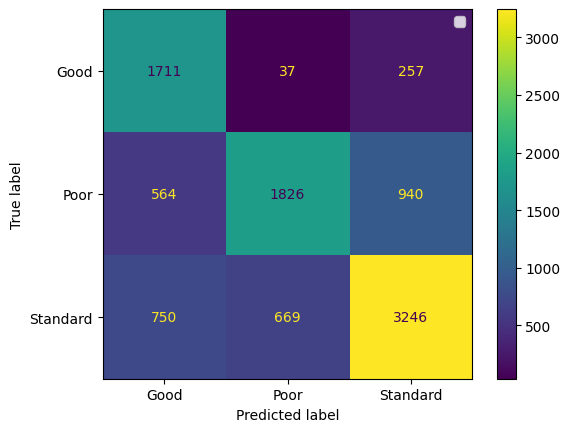

              precision    recall  f1-score   support

        Good       0.57      0.85      0.68      2005
        Poor       0.72      0.55      0.62      3330
    Standard       0.73      0.70      0.71      4665

    accuracy                           0.68     10000
   macro avg       0.67      0.70      0.67     10000
weighted avg       0.69      0.68      0.68     10000



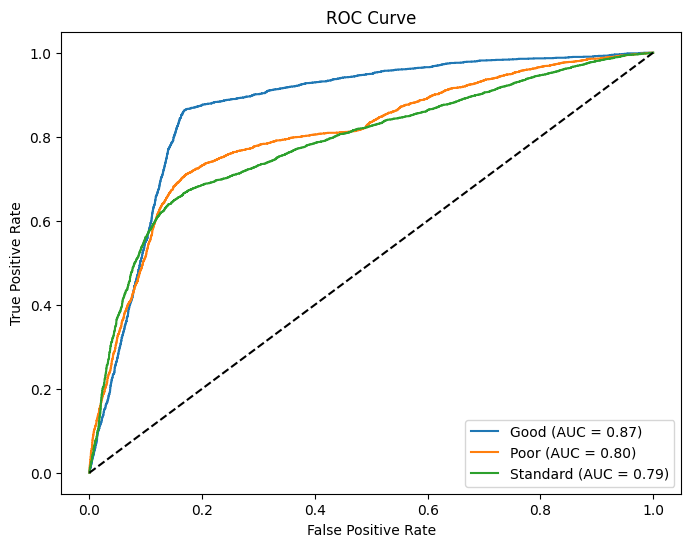

Métricas de Avaliação de Teste: 


/tmp/ipykernel_24192/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


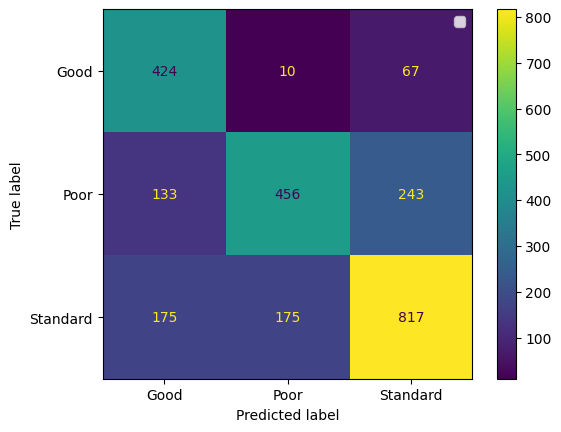

              precision    recall  f1-score   support

        Good       0.58      0.85      0.69       501
        Poor       0.71      0.55      0.62       832
    Standard       0.72      0.70      0.71      1167

    accuracy                           0.68      2500
   macro avg       0.67      0.70      0.67      2500
weighted avg       0.69      0.68      0.68      2500



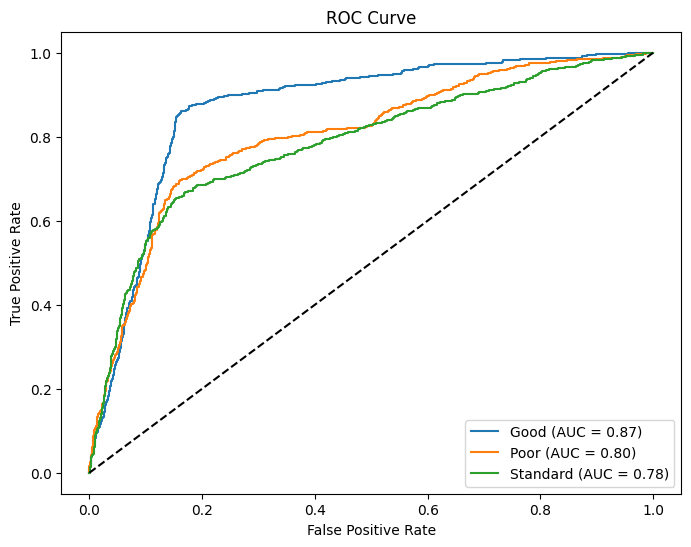

In [149]:
Metrics_Classification(svm_model, X_train_preprocessed, X_test_preprocessed, Y_train, Y_test)

Ao comparar os resultados de treino e teste, apesar do resultado ser apenas razoável (acurácia de 0,68 nos treinos e testes), observa-se que não houve overfitting. Considerando que se trata de um classificador de score de crédito, o pior erro cometido pelo modelo é classificar um mal pagador como bom pagador, resultando na concessão indevida de crédido. Dito isso, a métrica precision ganha relevância sobre o recall. Esse erro corresponde ao Falso negativo da classe Poor, tornando o recall dela a métrica mais relevante.

Dito isso, o modelo apresentam desempenho insatisfatório pois consegue identificar apenas 55% dos clientes maus pagadores, o que é bem próximo da aleatoriedade. A classe Good apresenta o maior recall (0,85), assim como a melhor AUC, indicando que é bom em identificar verdadeiros bons pagadores. Sua precisão, por outro lado, de apenas 0,58 indica que o modelo tende a classificar clientes como Good quando não o são, o que pode indicar concessão de crédito indevida ou acima da capacidade de pagamento do cliente.

### Modelos de Boosting

In [150]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train_preprocessed, Y_train)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


Métricas de Avaliação de Treino: 


/tmp/ipykernel_24192/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


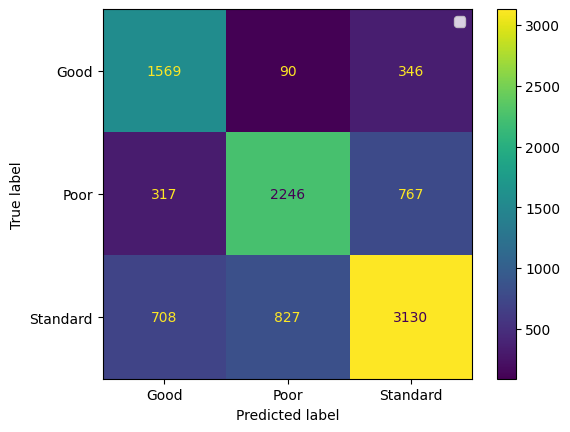

              precision    recall  f1-score   support

        Good       0.60      0.78      0.68      2005
        Poor       0.71      0.67      0.69      3330
    Standard       0.74      0.67      0.70      4665

    accuracy                           0.69     10000
   macro avg       0.68      0.71      0.69     10000
weighted avg       0.70      0.69      0.70     10000



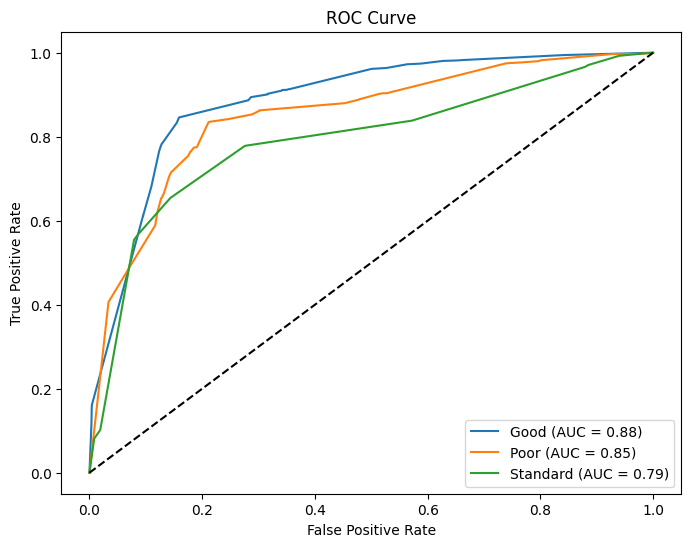

Métricas de Avaliação de Teste: 


/tmp/ipykernel_24192/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


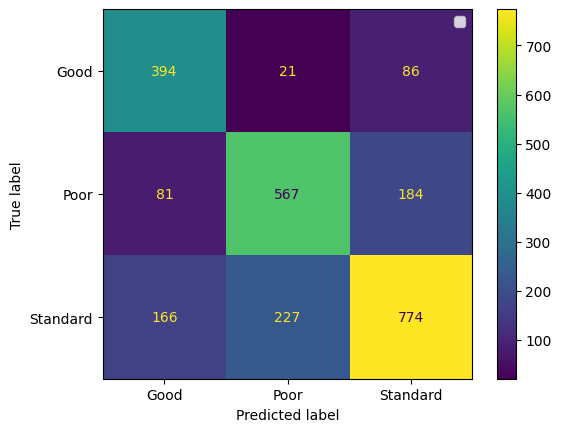

              precision    recall  f1-score   support

        Good       0.61      0.79      0.69       501
        Poor       0.70      0.68      0.69       832
    Standard       0.74      0.66      0.70      1167

    accuracy                           0.69      2500
   macro avg       0.68      0.71      0.69      2500
weighted avg       0.70      0.69      0.69      2500



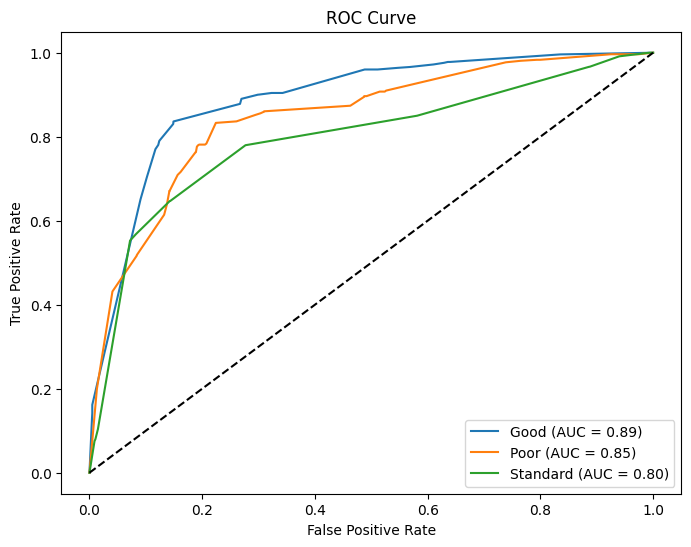

In [151]:
Metrics_Classification(adaboost_model, X_train_preprocessed, X_test_preprocessed, Y_train, Y_test)

O AdaBoosting apresentou desempenhos semelhantes em treino e teste, indicando ausência de overfitting. O modelo identifica melhor clientes da classe Good (maior recall), enquanto o melhor percentual de acerto nas classificações ocorre na classe Standard (melhor precision).

A classe Good apresenta melhor AUC em função de sua maior capacidade de identificar os clientes que realmente são bons pagadores. A classe Poor apresenta a segunda melhor AUC em decorrência do equilíbrio entre precisão e recall.

Considerando o risco de crédito, o recall da classe Poor de 0,68 é a métrica mais importante. O modelo não identifica 32% dos maus pagadores. Além disso, a precisão mais baixa da classe Good (0,61) indica que alguns clientes classificados como bons pagadores podem não o ser, o que pode resultar em concessão de crédito acima da capacidade real de pagamento ou indevida.

Ao comparar os dois modelos, o AdaBoost se mostra mais adequado como classificador de score de crédito, com recall de Poor de 0,68 contra 0,55 do SVM, identificando um percentual maior de maus pagadores. Apesar disso, o recall de ambos é apenas razoável, o que significa que o AdaBoost só pode ser considerado mais conservador em comparação ao SVM, mas não em termos absolutos.

## Escolha de hiperparâmetros

A fim de melhorar o desempenho dos modelos, podemos testar vários hiperparâmentros. Para tornar o processo mais prático, criarei uma lista de dicionários, sendo um para cada modelo, com os respectivos hiperparâmetros a serem testados.

In [154]:
models = [
    {

        'name': "AdaBoostClassifier",
        'model': AdaBoostClassifier(random_state=42),
        'paramns': {
            'n_estimators': [75, 90, 120, 150, 200],                 # Número de estimadores fracos (por padrão, árvores rasas)
            'learning_rate': [1.0, 1.2, 1.5],                   # Taxa de aprendizado — controla o peso de cada estimador
        }
    },
    {
        'name': "SVC",
        'model': SVC(random_state=42),
        'paramns':
            {
                "kernel": ["linear", "rbf"],            #função de transformação de dimensionalidade
                "C": np.logspace(-2, 2, 4),                     #representa o quão suave o modelo será. Quanto menor, mais suável.
                "gamma": np.logspace(-2, 2, 4)                  #influência de cada ponto na fronteira de decisão. Alto gama = somente pontos próximos são considerados.
            }

    }
]

## Treinamento dos modelos


Para otimizar ainda mais o processo, podemos usar o GridSearchCV, que testará todas as combinações de parâmetros do modelo. Usarei um loop para iterar sobre o dicionário, e aplicar o RandomizedSearchCV em cada modelo e guardar os resultados da melhor cominação no respectivo dicionário. 

Como o volume de dado sé alto, troquei o GridSearchCV pelo RandomizedSearchCV, pois este não testa todas as possibilidades mas as escolhe aleatoriamente, reduzindo o número de treinamentos.

Além disso, usarei o StratifiedKFold, a fim de reduzir a possibilidade de que qualquer modelo, em qualquer combinação de hiperparâmetros apresente overfitting. O StratifiedKFold, mantem a proporção do target dos dados originiais, o que é importante visto que as classes estão desbalanceadas.

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END learning_rate=1.0, n_estimators=75; accuracy: (train=0.711, test=0.702) f1: (train=0.712, test=0.702) precision: (train=0.726, test=0.713) recall: (train=0.711, test=0.702) total time=   3.9s
[CV 2/5] END learning_rate=1.0, n_estimators=75; accuracy: (train=0.718, test=0.707) f1: (train=0.719, test=0.708) precision: (train=0.731, test=0.722) recall: (train=0.718, test=0.707) total time=   4.0s
[CV 3/5] END learning_rate=1.0, n_estimators=75; accuracy: (train=0.715, test=0.720) f1: (train=0.717, test=0.721) precision: (train=0.727, test=0.732) recall: (train=0.715, test=0.720) total time=   4.1s
[CV 5/5] END learning_rate=1.0, n_estimators=75; accuracy: (train=0.713, test=0.715) f1: (train=0.715, test=0.716) precision: (train=0.724, test=0.726) recall: (train=0.713, test=0.715) total time=   4.8s
[CV 1/5] END learning_rate=1.5, n_estimators=90; accuracy: (train=0.708, test=0.705) f1: (train=0.710, test=0.706) prec

,param_n_estimators,param_learning_rate,mean_fit_time,std_fit_time,mean_score_time,std_score_time,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1
7,200,1.0,13.154857,0.345895,0.151981,0.068289,0.7109,0.006208,0.712825,0.002417,0.725421,0.006810,0.726911,0.003300,0.7109,0.006208,0.712825,0.002417,0.712679,0.006241,0.714535,0.002440
2,150,1.0,10.340386,0.809077,0.240295,0.042571,0.7104,0.006553,0.714000,0.004122,0.723576,0.006904,0.726962,0.004964,0.7104,0.006553,0.714000,0.004122,0.711917,0.006537,0.715534,0.004091
1,75,1.0,4.211528,0.427622,0.166253,0.031708,0.7106,0.006296,0.713550,0.002783,0.723451,0.006249,0.726319,0.002655,0.7106,0.006296,0.713550,0.002783,0.711976,0.006386,0.714965,0.002719
3,120,1.5,8.579408,0.495045,0.198516,0.029727,0.7077,0.008078,0.712200,0.003519,0.723234,0.009604,0.728272,0.005525,0.7077,0.008078,0.712200,0.003519,0.709325,0.008389,0.714087,0.003691
8,120,1.0,8.367537,0.474386,0.211802,0.072754,0.7096,0.006053,0.711925,0.004703,0.722507,0.006933,0.724636,0.005640,0.7096,0.006053,0.711925,0.004703,0.711105,0.006114,0.713432,0.004692
5,90,1.2,6.509305,0.347300,0.172436,0.040280,0.7067,0.006377,0.710025,0.004814,0.722242,0.006784,0.726371,0.004298,0.7067,0.006377,0.710025,0.004814,0.708636,0.006232,0.711961,0.005019
0,90,1.5,5.714532,0.180865,0.198142,0.043536,0.7068,0.007075,0.709775,0.002073,0.722218,0.008296,0.725649,0.003896,0.7068,0.007075,0.709775,0.002073,0.708324,0.007378,0.711679,0.002222
6,90,1.0,6.557124,0.365365,0.208989,0.064104,0.7080,0.007457,0.711525,0.001413,0.721652,0.006529,0.724939,0.001998,0.7080,0.007457,0.711525,0.001413,0.709628,0.007288,0.713090,0.001483
4,120,1.2,8.715130,0.535485,0.245531,0.056573,0.7066,0.006880,0.710325,0.005267,0.721284,0.007372,0.725731,0.005228,0.7066,0.006880,0.710325,0.005267,0.708501,0.006853,0.712229,0.005515
9,75,1.2,4.407789,0.468421,0.101366,0.031634,0.7027,0.007434,0.707575,0.003315,0.717466,0.007581,0.723567,0.003297,0.7027,0.007434,0.707575,0.003315,0.704414,0.007211,0.709425,0.003543


Métricas de Avaliação de Treino: 


/tmp/ipykernel_24192/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


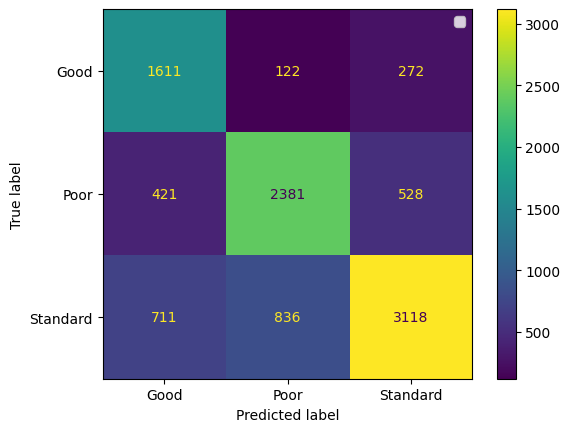

              precision    recall  f1-score   support

        Good       0.59      0.80      0.68      2005
        Poor       0.71      0.72      0.71      3330
    Standard       0.80      0.67      0.73      4665

    accuracy                           0.71     10000
   macro avg       0.70      0.73      0.71     10000
weighted avg       0.73      0.71      0.71     10000



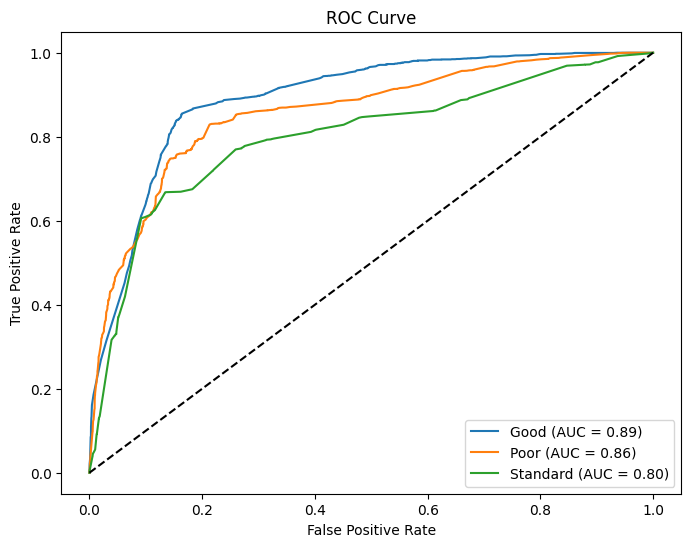

Métricas de Avaliação de Teste: 


/tmp/ipykernel_24192/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


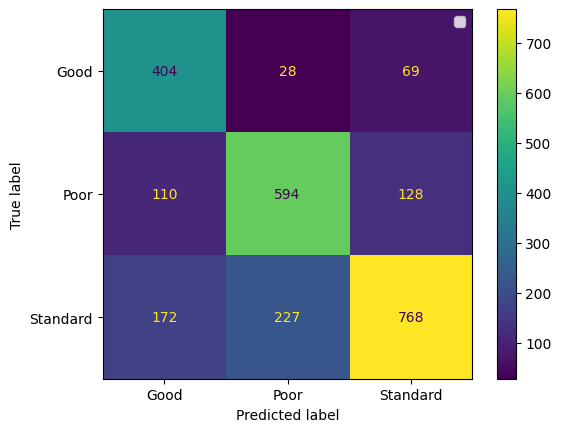

              precision    recall  f1-score   support

        Good       0.59      0.81      0.68       501
        Poor       0.70      0.71      0.71       832
    Standard       0.80      0.66      0.72      1167

    accuracy                           0.71      2500
   macro avg       0.69      0.73      0.70      2500
weighted avg       0.72      0.71      0.71      2500



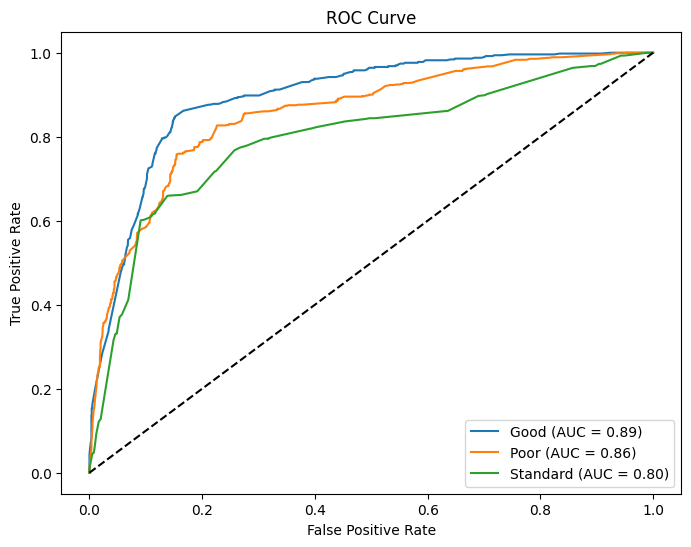

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END C=0.01, gamma=4.6415888336127775, kernel=linear; accuracy: (train=0.674, test=0.670) f1: (train=0.671, test=0.668) precision: (train=0.691, test=0.684) recall: (train=0.674, test=0.670) total time=  14.8s
[CV 3/5] END C=0.01, gamma=4.6415888336127775, kernel=linear; accuracy: (train=0.674, test=0.675) f1: (train=0.671, test=0.673) precision: (train=0.690, test=0.690) recall: (train=0.674, test=0.675) total time=  15.1s
[CV 5/5] END C=0.01, gamma=4.6415888336127775, kernel=linear; accuracy: (train=0.671, test=0.672) f1: (train=0.668, test=0.669) precision: (train=0.687, test=0.687) recall: (train=0.671, test=0.672) total time=  16.0s
[CV 2/5] END C=0.01, gamma=4.6415888336127775, kernel=linear; accuracy: (train=0.675, test=0.680) f1: (train=0.673, test=0.680) precision: (train=0.691, test=0.699) recall: (train=0.675, test=0.680) total time=  14.3s
[CV 4/5] END C=0.01, gamma=4.6415888336127775, kernel=linear; accur

/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5] END C=0.01, gamma=0.01, kernel=linear; accuracy: (train=0.675, test=0.680) f1: (train=0.673, test=0.680) precision: (train=0.691, test=0.699) recall: (train=0.675, test=0.680) total time=  12.1s
[CV 1/5] END C=0.01, gamma=0.01, kernel=linear; accuracy: (train=0.674, test=0.670) f1: (train=0.671, test=0.668) precision: (train=0.691, test=0.684) recall: (train=0.674, test=0.670) total time=  14.6s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5] END C=4.6415888336127775, gamma=4.6415888336127775, kernel=linear; accuracy: (train=0.680, test=0.676) f1: (train=0.679, test=0.674) precision: (train=0.697, test=0.691) recall: (train=0.680, test=0.676) total time=  39.7s
[CV 1/5] END C=4.6415888336127775, gamma=4.6415888336127775, kernel=linear; accuracy: (train=0.678, test=0.673) f1: (train=0.676, test=0.672) precision: (train=0.696, test=0.687) recall: (train=0.678, test=0.673) total time=  40.8s
[CV 4/5] END C=4.6415888336127775, gamma=4.6415888336127775, kernel=linear; accuracy: (train=0.679, test=0.673) f1: (train=0.678, test=0.669) precision: (train=0.695, test=0.691) recall: (train=0.679, test=0.673) total time=  41.9s
[CV 5/5] END C=4.6415888336127775, gamma=4.6415888336127775, kernel=linear; accuracy: (train=0.671, test=0.672) f1: (train=0.668, test=0.669) precision: (train=0.686, test=0.687) recall: (train=0.671, test=0.672) total time=  44.5s
[CV 2/5] END C=4.6415888336127775, gamma=4.6415888336127775, kernel=line

/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5] END C=0.21544346900318834, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  34.9s
[CV 3/5] END C=0.01, gamma=0.01, kernel=linear; accuracy: (train=0.674, test=0.675) f1: (train=0.671, test=0.673) precision: (train=0.690, test=0.690) recall: (train=0.674, test=0.675) total time=  12.7s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5] END C=0.01, gamma=0.01, kernel=linear; accuracy: (train=0.674, test=0.671) f1: (train=0.671, test=0.667) precision: (train=0.689, test=0.689) recall: (train=0.674, test=0.671) total time=  14.2s
[CV 1/5] END C=0.01, gamma=0.21544346900318834, kernel=linear; accuracy: (train=0.674, test=0.670) f1: (train=0.671, test=0.668) precision: (train=0.691, test=0.684) recall: (train=0.674, test=0.670) total time=  12.6s
[CV 5/5] END C=0.01, gamma=0.01, kernel=linear; accuracy: (train=0.671, test=0.672) f1: (train=0.668, test=0.669) precision: (train=0.687, test=0.687) recall: (train=0.671, test=0.672) total time=  14.1s
[CV 2/5] END C=0.01, gamma=0.21544346900318834, kernel=linear; accuracy: (train=0.675, test=0.680) f1: (train=0.673, test=0.680) precision: (train=0.691, test=0.699) recall: (train=0.675, test=0.680) total time=  13.5s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 1/5] END C=0.21544346900318834, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  47.0s
[CV 4/5] END C=0.01, gamma=0.21544346900318834, kernel=linear; accuracy: (train=0.674, test=0.671) f1: (train=0.671, test=0.667) precision: (train=0.689, test=0.689) recall: (train=0.674, test=0.671) total time=  14.4s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5] END C=0.01, gamma=0.21544346900318834, kernel=linear; accuracy: (train=0.674, test=0.675) f1: (train=0.671, test=0.673) precision: (train=0.690, test=0.690) recall: (train=0.674, test=0.675) total time=  14.8s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 5/5] END C=0.21544346900318834, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  39.9s
[CV 5/5] END C=0.01, gamma=0.21544346900318834, kernel=linear; accuracy: (train=0.671, test=0.672) f1: (train=0.668, test=0.669) precision: (train=0.687, test=0.687) recall: (train=0.671, test=0.672) total time=  15.7s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5] END C=0.21544346900318834, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  42.4s
[CV 1/5] END C=0.21544346900318834, gamma=0.01, kernel=rbf; accuracy: (train=0.687, test=0.683) f1: (train=0.686, test=0.683) precision: (train=0.705, test=0.697) recall: (train=0.687, test=0.683) total time=  19.1s
[CV 4/5] END C=0.21544346900318834, gamma=0.01, kernel=rbf; accuracy: (train=0.689, test=0.680) f1: (train=0.689, test=0.678) precision: (train=0.706, test=0.699) recall: (train=0.689, test=0.680) total time=  18.1s
[CV 3/5] END C=0.21544346900318834, gamma=0.01, kernel=rbf; accuracy: (train=0.688, test=0.680) f1: (train=0.687, test=0.679) precision: (train=0.706, test=0.695) recall: (train=0.688, test=0.680) total time=  20.6s
[CV 2/5] END C=0.21544346900318834, gamma=0.01, kernel=rbf; accuracy: (train=0.691, test=0.691) f1: (train=0.690, test=0.692) precision

/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5] END C=0.21544346900318834, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  53.3s
[CV 5/5] END C=0.21544346900318834, gamma=0.01, kernel=rbf; accuracy: (train=0.688, test=0.688) f1: (train=0.688, test=0.687) precision: (train=0.705, test=0.705) recall: (train=0.688, test=0.688) total time=  20.1s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5] END C=4.6415888336127775, gamma=0.21544346900318834, kernel=linear; accuracy: (train=0.680, test=0.676) f1: (train=0.679, test=0.674) precision: (train=0.697, test=0.691) recall: (train=0.680, test=0.676) total time=  38.3s
[CV 2/5] END C=4.6415888336127775, gamma=0.21544346900318834, kernel=linear; accuracy: (train=0.681, test=0.686) f1: (train=0.680, test=0.687) precision: (train=0.697, test=0.706) recall: (train=0.681, test=0.686) total time=  39.4s
[CV 1/5] END C=4.6415888336127775, gamma=0.21544346900318834, kernel=linear; accuracy: (train=0.678, test=0.673) f1: (train=0.676, test=0.672) precision: (train=0.696, test=0.687) recall: (train=0.678, test=0.673) total time=  40.7s
[CV 4/5] END C=4.6415888336127775, gamma=0.21544346900318834, kernel=linear; accuracy: (train=0.679, test=0.673) f1: (train=0.678, test=0.669) precision: (train=0.695, test=0.691) recall: (train=0.679, test=0.673) total time=  38.5s
[CV 5/5] END C=4.6415888336127775, gamma=0.21544346900318834, kernel

/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

[CV 2/5] END C=0.01, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  28.8s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 1/5] END C=100.0, gamma=4.6415888336127775, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  33.1s
[CV 2/5] END C=100.0, gamma=4.6415888336127775, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  33.4s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

[CV 1/5] END C=0.01, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  48.7s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5] END C=100.0, gamma=4.6415888336127775, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  31.6s
[CV 4/5] END C=100.0, gamma=4.6415888336127775, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  33.3s
[CV 5/5] END C=0.01, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  41.0s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 4/5] END C=0.01, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  52.7s
[CV 5/5] END C=100.0, gamma=4.6415888336127775, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  34.1s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5] END C=0.01, gamma=100.0, kernel=rbf; accuracy: (train=0.467, test=0.467) f1: (train=0.297, test=0.297) precision: (train=0.218, test=0.218) recall: (train=0.467, test=0.467) total time=  46.2s
[CV 1/5] END C=4.6415888336127775, gamma=4.6415888336127775, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  31.2s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/5] END C=4.6415888336127775, gamma=4.6415888336127775, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  32.4s


/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/afonso_henrique/01DA766CB71B34D0/Trabalho ADA/.venv_u/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 3/5] END C=4.6415888336127775, gamma=4.6415888336127775, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  29.6s
[CV 4/5] END C=4.6415888336127775, gamma=4.6415888336127775, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  26.4s
[CV 5/5] END C=4.6415888336127775, gamma=4.6415888336127775, kernel=rbf; accuracy: (train=1.000, test=0.467) f1: (train=1.000, test=0.297) precision: (train=1.000, test=0.218) recall: (train=1.000, test=0.467) total time=  27.0s
SVC
Melhor Estimador: SVC(C=np.float64(0.21544346900318834), gamma=np.float64(0.01), random_state=42)
Melhores Parâmetros: {'kernel': 'rbf', 'gamma': np.float64(0.01), 'C': np.float64(0.21544346900318834)}
Melhor Score (validação): 0.6845


,param_kernel,param_gamma,param_C,mean_fit_time,std_fit_time,mean_score_time,std_score_time,mean_test_accuracy,std_test_accuracy,mean_train_accuracy,std_train_accuracy,mean_test_precision,std_test_precision,mean_train_precision,std_train_precision,mean_test_recall,std_test_recall,mean_train_recall,std_train_recall,mean_test_f1,std_test_f1,mean_train_f1,std_train_f1
5,rbf,0.010000,0.215443,17.450256,1.315826,2.542717,0.183895,0.6845,0.003950,0.688425,0.001308,0.701520,0.005852,0.705912,0.000962,0.6845,0.003950,0.688425,0.001308,0.683728,0.005175,0.688074,0.001393
0,linear,4.641589,4.641589,40.870428,2.365626,1.748531,0.105202,0.6763,0.005046,0.678075,0.003669,0.692350,0.006930,0.694159,0.003963,0.6763,0.005046,0.678075,0.003669,0.674153,0.006647,0.676153,0.004159
6,linear,0.215443,4.641589,37.746864,1.080957,1.830967,0.152147,0.6763,0.005046,0.678075,0.003669,0.692350,0.006930,0.694159,0.003963,0.6763,0.005046,0.678075,0.003669,0.674153,0.006647,0.676153,0.004159
1,linear,4.641589,0.010000,13.439032,0.881132,1.948949,0.056067,0.6739,0.003484,0.673700,0.001329,0.689826,0.005186,0.689494,0.001337,0.6739,0.003484,0.673700,0.001329,0.671360,0.004652,0.671064,0.001421
4,linear,0.215443,0.010000,12.755755,1.103650,1.448651,0.178275,0.6739,0.003484,0.673700,0.001329,0.689826,0.005186,0.689494,0.001337,0.6739,0.003484,0.673700,0.001329,0.671360,0.004652,0.671064,0.001421
3,linear,0.010000,0.010000,11.821109,0.967381,1.707454,0.101873,0.6739,0.003484,0.673700,0.001329,0.689826,0.005186,0.689494,0.001337,0.6739,0.003484,0.673700,0.001329,0.671360,0.004652,0.671064,0.001421
2,rbf,100.000000,0.215443,38.085070,6.631180,5.415547,1.109204,0.4665,0.000000,0.466500,0.000000,0.217622,0.000000,0.217622,0.000000,0.4665,0.000000,0.466500,0.000000,0.296791,0.000000,0.296791,0.000000
7,rbf,100.000000,0.010000,38.521464,7.169505,4.950174,1.362115,0.4665,0.000000,0.466500,0.000000,0.217622,0.000000,0.217622,0.000000,0.4665,0.000000,0.466500,0.000000,0.296791,0.000000,0.296791,0.000000
8,rbf,4.641589,100.000000,29.450143,0.847800,3.643524,0.268293,0.4665,0.000000,1.000000,0.000000,0.217622,0.000000,1.000000,0.000000,0.4665,0.000000,1.000000,0.000000,0.296791,0.000000,1.000000,0.000000
9,rbf,4.641589,4.641589,26.957004,1.780755,2.377620,0.899433,0.4665,0.000000,1.000000,0.000000,0.217622,0.000000,1.000000,0.000000,0.4665,0.000000,1.000000,0.000000,0.296791,0.000000,1.000000,0.000000


Métricas de Avaliação de Treino: 


/tmp/ipykernel_24192/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


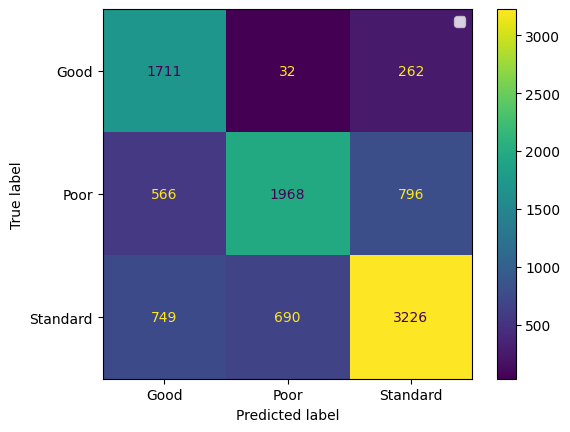

              precision    recall  f1-score   support

        Good       0.57      0.85      0.68      2005
        Poor       0.73      0.59      0.65      3330
    Standard       0.75      0.69      0.72      4665

    accuracy                           0.69     10000
   macro avg       0.68      0.71      0.68     10000
weighted avg       0.71      0.69      0.69     10000



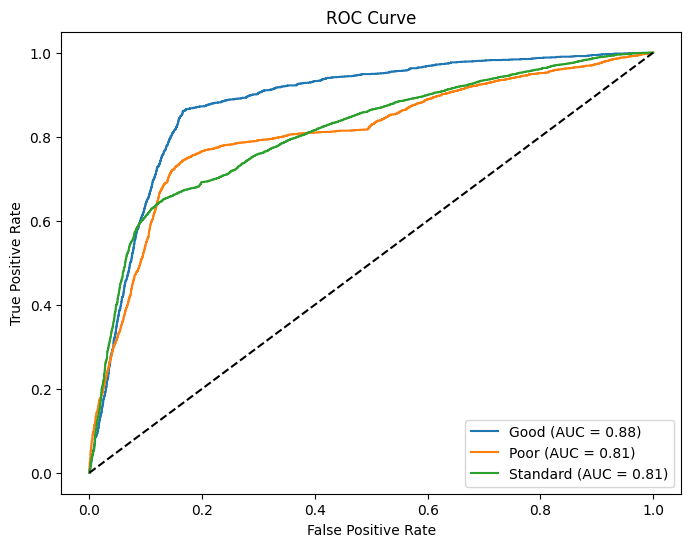

Métricas de Avaliação de Teste: 


/tmp/ipykernel_24192/808473536.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


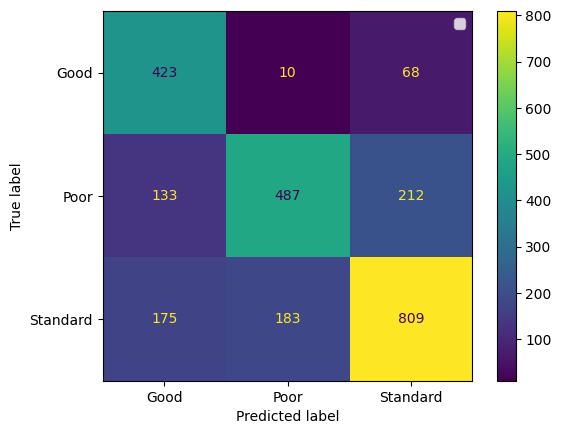

              precision    recall  f1-score   support

        Good       0.58      0.84      0.69       501
        Poor       0.72      0.59      0.64       832
    Standard       0.74      0.69      0.72      1167

    accuracy                           0.69      2500
   macro avg       0.68      0.71      0.68      2500
weighted avg       0.70      0.69      0.69      2500



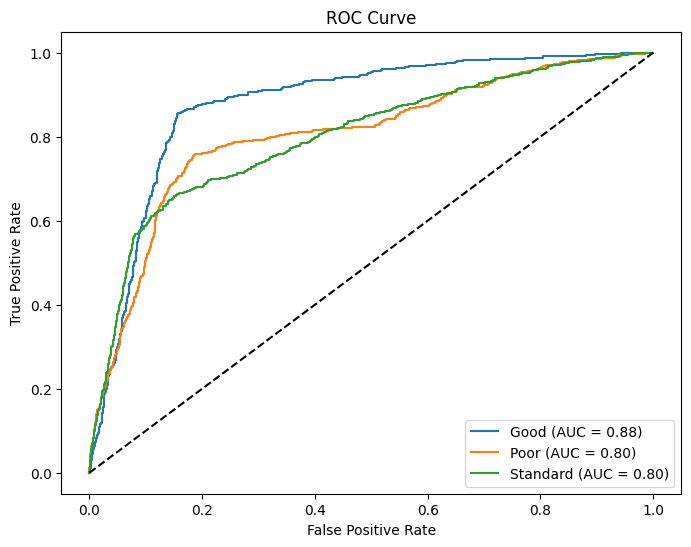

In [156]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #diviviu em 5 folds, com embarlhamento para garantir que um fold não terá prevalência de uma classe
for model in models:
    random = RandomizedSearchCV(
        estimator=model['model'],
        param_distributions=model['paramns'],
        cv=cv,
        verbose=5,
        n_jobs=-1,
        scoring=scoring,  # métricas de classificação
        refit='recall',
        return_train_score=True,
        n_iter=10
    )

    random.fit(X_train_preprocessed, Y_train)

    print(model['name'])

    print('Melhor Estimador:', random.best_estimator_)
    print('Melhores Parâmetros:', random.best_params_)
    print('Melhor Score (validação):', random.best_score_)

    model['estimador'] = random.best_estimator_
    model['best_paramns'] = random.best_params_
    model['score'] = random.best_score_
    model['results'] = random.cv_results_

    df = pd.DataFrame(random.cv_results_)

    # Seleciona apenas colunas de parâmetros + médias e desvios
    cols_param = [c for c in df.columns if c.startswith('param_')]
    cols_mean_std = [c for c in df.columns if c.startswith('mean_') or c.startswith('std_')]

    df_media = df[cols_param + cols_mean_std]

    # Ordena pelo melhor recall médio
    df_media = df_media.sort_values('mean_test_precision', ascending=False)

    display(df_media)

    Metrics_Classification(model['estimador'], X_train_preprocessed, X_test_preprocessed, Y_train, Y_test)

## Avaliação de desempenho de modelo


Após o ajuste de hiperparâmetros, os modelos obtiveram leves ganhos de desempenho em comparação às suas versões padrão.

O AdaBoostClassifier obteve seu melhor resultado com n_estimators=200 e learning_rate=1.0, obtendo precisão média ponderada de 0,72. No conjunto de teste a acurácia atingiu 0,71, com melhora principalmente na classe Standard, cuja precisão saiu de 0,74 (versão padrão) para 0,80. O modelo manteve resultados semelhantes em treino e teste, confirmando ausência de overfitting. A classe Poor apresentou recall de 0,71, contra 0,68 no modelo padrão, o que significa que o modelo tem maior capacidade de identificar maus pagadores. Isso indica um comportamento conservador ao conceder crédito.

O SVC obteve acurácia de 0,69 tanto no treino quanto no teste, com precisão média ponderada de 0,70. A classe Poor apresentou precisão de 0,74 e recall de 0,59 no teste, indicando que o modelo erra pouco quando aponta alguém como mau pagador, mas deixa escapar uma parcela relevante deles. A consistência entre treino e teste indica ausência de overfitting.

Ao comparar os dois modelos após a otimização de hiperparâmetros, observa-se que o AdaBoost se mostrou superior, atingindo acurácia de 0,71 no teste contra 0,69 do SVC. Para um modelo classificador de score de crédito, o pior cenário é classificar um mau pagador como bom. Isso diz respeito ao recall da classe Poor, que representa a proporção de acerto dentre aqueles que são de fato maus pagadores. O AdaBoost se mostra mais adequado nesse aspecto, com recall de 0,71 contra 0,59 do SVC, ou seja, o AdaBoost deixa escapar menos maus pagadores. O SVC, por sua vez, apresenta precisão mais alta nessa classe (0,74 vs 0,70), o que significa que erra menos quando aponta alguém como mau pagador, mas identifica uma proporção menor deles no total.

# CAPÍTULO 2: APRENDIZADO NÃO-SUPERVISIONADO

## Contexto

Este conjunto de dados, coletado por meio de uma plataforma de varejo online, oferece informações abrangentes sobre os hábitos de compra do consumidor. Ele registra diferentes facetas do comportamento do consumidor, como padrões de transação, preferências de compra e informações demográficas. O objetivo do conjunto de dados é auxiliar na análise de tendências de compra, na avaliação do impacto de variáveis ​​como sazonalidade, métodos de pagamento e descontos nas decisões de compra, e na compreensão da relação entre as características do consumidor, as escolhas de produtos e os padrões de gastos. (kaggle)

### Features Disponíveis

- Customer ID:                                  Identificador único do cliente
- Age:                                          Idade do cliente
- Gender:                                       Gênero do cliente
- Item Purchased:                               Nome do produto comprado
- Category:                                     Tipo de categoria do produto
- Purchase Amount (USD):                        Custo total da compra
- Location:                                     Localização geográfica do cliente
- Size:                                         Tamanho do item comprado
- Color:                                        Cor do item escolhido
- Season:                                       Período de estação da compra
- Review Rating:                                Avaliação da compra
- Subscription Status:                          Status de assinatura
- Shipping Type:                                Tipo de envio
- Discount Applied:                             Desconto aplicado
- Promo Code Used:                              Código promocional utilizado
- Previous Purchases:                           Compras anteriores
- Payment Method:                               Método de pagamento
- Frequency of Purchases:                       Frequência de compras

Fonte: Kaggle

## Carregamento dos dados

In [1]:
!pip install pandas

In [2]:
import pandas as pd
X = pd.read_csv(r"./data/shopping_behavior_updated.csv")

## Análise Exploratória dos Dados

In [3]:
X

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [4]:
X.info()
X["Age"]

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

0       55
1       19
2       50
3       21
4       45
        ..
3895    40
3896    52
3897    46
3898    44
3899    52
Name: Age, Length: 3900, dtype: int64

A função info() mostra que as features estão no formato correto e não há valores nulos. Trata-se então de dados limpos.

## Pré-Processamento

In [5]:
!pip install scikit-learn numpy

Uso o OneHotEncoder para transformar colunas categóricas em numéricas e o StandardScaler para evitar que os modelos dê importância mais importância a uma feature numérica do que a outra em função da diferença entre escala de dados.

Além disso, excluo a coluna Customer ID visto que esta não possui valor para o modelo.

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler


import numpy as np

X_mod = X.drop(columns="Customer ID", errors='ignore')

num_features = X_mod.select_dtypes(include=np.number).columns.tolist()
cat_features = X_mod.select_dtypes(exclude=np.number).columns.tolist()

scaler = StandardScaler()
X_mod[num_features] = scaler.fit_transform(X[num_features])

encoder = OneHotEncoder()
X_cat_encoded = encoder.fit_transform(X[cat_features])

X_preprocessed = np.hstack((X_mod[num_features], X_cat_encoded.toarray()))

cat_cols = encoder.get_feature_names_out(cat_features).tolist()

all_cols = num_features + cat_cols


X["Age"]

0       55
1       19
2       50
3       21
4       45
        ..
3895    40
3896    52
3897    46
3898    44
3899    52
Name: Age, Length: 3900, dtype: int64

## Fuções Para Calcular Métricas

Crio a Função Obter_Métricas que calcula e printa as métricas Silhouette Coefficient, Davies-Bouldin Index, Calinski-Harabasz Index. A função pode ser reutilizada na aplicação de cada modelo. 

O Silhouette Coefficient varia entre -1 e 1. Quanto mais próximo de 1 melhor. Este mede tanto a coesão intragrupo quanto a separação intergrupos.

As outras duas métricas, medem tanto a similaridade intragrupo como a dissimilaridade intergrupos. A Calinski-Harabasz Index é do tipo quanto maior melhor, enquanto o Davies-Bouldin Index é do tipo quanto menor melhor.

In [7]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def Obter_Métricas(X, y_pred):
    silhouette = silhouette_score(X, y_pred)
    davies_bouldin = davies_bouldin_score(X, y_pred)
    calinski_harabasz_index = calinski_harabasz_score(X, y_pred)

    return round(silhouette,4), round(davies_bouldin,4), round(calinski_harabasz_index,4)

    

## K-Means

Utilizando alguns loops For, testo uma combinação de parâmetros para encontrar a melhor combinação. Os resultados são armazenados em um Data Frame Pandas e são ordenados de forma que os melhores modelos ocupam os primeiros índices. 

O parâmetro:
- n_clusters indica o número de grupos que o algoritmo deve formar.
- tol define o critério utilizado para identificar a convergência do modelo. Quanto menor a tolerância, mas preciso o modelo precisa ser. Representa a variação obtida entre uma iteração e outra para que o algoritmo se dê por satisfeito (pare de iterar).
- max_iter define o número máximo de iterações que serão realizadas em busca da convergência. Logo o modelo para ao atingir a convergência ou o número máximo de iterações, o que ocorrer primeiro.

In [8]:
from sklearn.cluster import KMeans

clusters = range(3, 6)

n_clusters_values = [2, 3, 4]
tolerance_values = [1e-4, 1e-3, 1e-2]
max_iter_values = [50, 100, 500, 1000]

results = []
for n_clusters in n_clusters_values:
    for tol in tolerance_values:
        for max_iter in max_iter_values:
            kmeans = KMeans(n_clusters=n_clusters, tol=tol, max_iter=max_iter)
            y_pred = kmeans.fit_predict(X_preprocessed)

            silhouette, davies_bouldin, calinski_harabasz_index = Obter_Métricas(X_preprocessed, y_pred)

            results.append(
                {
                   "Silhouette Coefficient": silhouette,
                   "Davies-Bouldin Index": davies_bouldin,
                   "Calinski-Harabasz Index": calinski_harabasz_index,
                   "Nº de Clusters": n_clusters,
                   "Tolerância": tol,
                   "Nº Máximo de Iterações": max_iter
                }
            )


df_kmeans = pd.DataFrame(results).sort_values(by=["Silhouette Coefficient", "Davies-Bouldin Index", "Calinski-Harabasz Index", "Tolerância", "Nº Máximo de Iterações"], ascending=[False, True, False, False, True])


display(df_kmeans)
df_kmeans['Modelo'] = 'k-Means'


,Silhouette Coefficient,Davies-Bouldin Index,Calinski-Harabasz Index,Nº de Clusters,Tolerância,Nº Máximo de Iterações
8,0.0983,2.9653,432.1102,2,0.0100,50
9,0.0983,2.9653,432.1102,2,0.0100,100
10,0.0983,2.9653,432.1102,2,0.0100,500
11,0.0983,2.9653,432.1102,2,0.0100,1000
4,0.0983,2.9653,432.1102,2,0.0010,50
5,0.0983,2.9653,432.1102,2,0.0010,100
6,0.0983,2.9653,432.1102,2,0.0010,500
7,0.0983,2.9653,432.1102,2,0.0010,1000
0,0.0983,2.9653,432.1102,2,0.0001,50
1,0.0983,2.9653,432.1102,2,0.0001,100


Os melhores coeficientes foram obtidos com 2 clusters, tolerância de 0.01 e 50 iterações. Os 11 primeiros modelos são equivalentes ao observar apenas os resultados das métricas, mas em termos de eficiência o primeiro modelo foi melhor por precisar de menos iterações que os demais.



## DBSCAN 

No DBSCAN os parâmetros testados foram:

- eps: define o raio da vizinhanca de cada ponto. Se a distância entre dois pontos for menor que o valor de eps, então são considerados vizinhos. Quanto menor o valor, maior a probabilidade de um ponto ser classificado como ruído e de haver mais clusters. Quanto maiores os valores, maior a probabilidade de resultar em menos clusters.

- min_samples: estabelece o número mínimo de pontos dentro da vizinhança de um ponto para que este seja considerado um ponto central. Caso um ponto não atingem esse mínimo então o ponto é classificado como ruído.

Como o DBSCAN detecta o número de clusters automaticamente, apliquei uma condição para considerar apenas combinações de parâmetros que resultarem entre 2 e 5 clusters.

In [9]:
from sklearn.cluster import DBSCAN
import numpy as np

eps_values = np.arange(0.1, 5.0, 0.1)
min_samples_values = range(3, 15)

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)

        y_pred = dbscan.fit_predict(X_preprocessed)


        labels = np.unique(y_pred)
        n_clusters = len(labels[labels != -1])  

        if 2 <= n_clusters <= 5:
            
            silhouette, davies_bouldin, calinski_harabasz_index =  Obter_Métricas(X_preprocessed, y_pred)

            results.append(
                {
                   "Silhouette Coefficient": silhouette,
                   "Davies-Bouldin Index": davies_bouldin,
                   "Calinski-Harabasz Index": calinski_harabasz_index,
                   "Nº de Clusters": n_clusters,
                   "Eps": round(eps,1),
                   "Min Samples": min_samples,
                }
            )


df_dbscan = pd.DataFrame(results).sort_values(by=["Silhouette Coefficient", "Davies-Bouldin Index", "Calinski-Harabasz Index"], ascending=[False, True, False])


display(df_dbscan)

df_dbscan['Modelo'] = 'DBSCAN'


,Silhouette Coefficient,Davies-Bouldin Index,Calinski-Harabasz Index,Nº de Clusters,Eps,Min Samples
5,0.0014,6.5957,4.3986,2,3.5,3
11,-0.0089,5.8390,9.7967,2,3.6,13
8,-0.0118,7.1315,8.1361,2,3.5,6
9,-0.0172,7.9747,8.3901,2,3.5,7
6,-0.0371,5.5492,4.1659,3,3.5,4
7,-0.0638,4.3631,4.0290,5,3.5,5
0,-0.0702,1.7356,2.1778,2,2.7,3
10,-0.0711,5.9523,7.2591,4,3.5,8
4,-0.0869,2.7960,4.4796,4,3.3,12
3,-0.1071,2.5934,4.2520,3,3.2,8


O melhor resultado foi obtido com 2 clusters, Eps de 3.5 e min_samples igual a 3, atingindo Silhouette Coefficient de 0.0014, Davies-Bouldin Index de 6.5957 e Calinski-Harabasz Index de 4.3986.

O Silhouette Coefficient próximo de zero e o Davies-Bouldin Index elevado indicam que os pontos que formam cada cluster não são similares internamente e dissimilares em comparação a pontos de outros clusters. 


## Agglomerative Clustering



NO Agglomerative Clustering, os parâmetros testados foram:

- linkage: define o critério para medir a distância entre dois grupos, no qual quando o valor é:
    - Single: a distância entre dois clusters é igual a distância entre o part de pontos mais próximos, sendo um de cada cluster.
    - Complete: a distância entre dois clusters é definida pelo par de pontos mais distantes, sendo um ponto de cada cluster.
    - Average: a distância nesse caso é a média de todas as distâncias entre os pontos dos dois clusters.
- n_clusters: define o número de grupos a serem extraídos da hierarquia. 

Para cada método de linkage, printo um Dendrograma para visualizar como os clusters são formados hierarquicamente. 

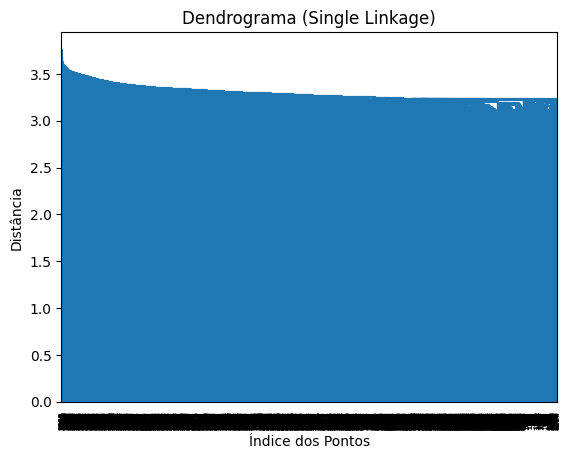

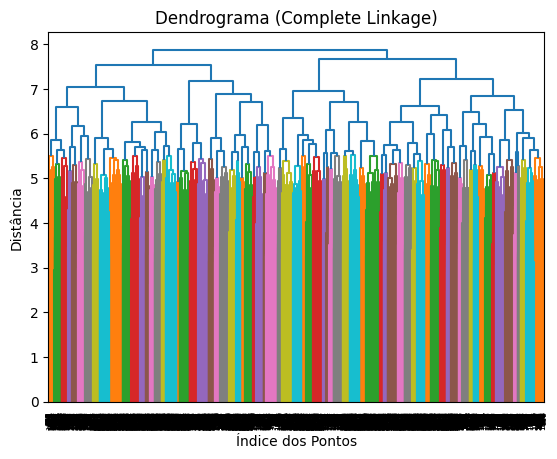

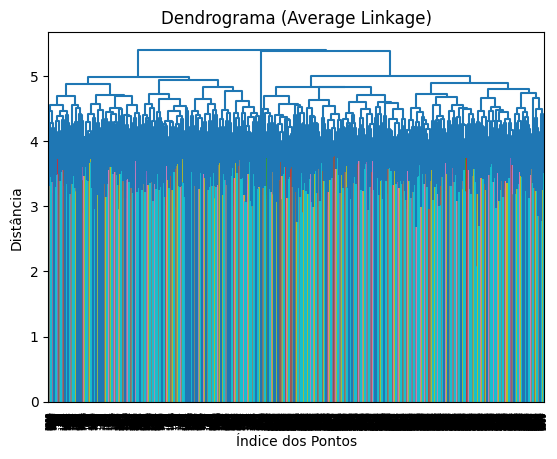

,Silhouette Coefficient,Davies-Bouldin Index,Calinski-Harabasz Index,Nº de Clusters,Linkage Method
8,0.0980,2.9704,430.6223,2,average
0,0.0714,0.8561,1.3568,2,single
9,0.0681,2.2575,216.0526,3,average
10,0.0475,3.0744,186.6195,4,average
4,0.0380,4.8869,161.4905,2,complete
11,0.0339,3.7182,162.7565,5,average
5,0.0255,4.4176,133.8473,3,complete
6,0.0239,4.3480,122.3902,4,complete
7,0.0230,3.8601,134.8416,5,complete
1,0.0177,0.8523,1.3751,3,single


In [10]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linkage_methods = ['single', 'complete', 'average']
clusters = range(2, 6)

results = []

for linkage_method in linkage_methods:
    linkage_matrix = linkage(X_preprocessed, method=linkage_method)
    dendrogram(linkage_matrix)

    plt.title(f'Dendrograma ({linkage_method.capitalize()} Linkage)')
    plt.xlabel('Índice dos Pontos')
    plt.ylabel('Distância')
    plt.show()

    for n in clusters:
        model = AgglomerativeClustering(n_clusters=n, linkage=linkage_method)
        y_pred = model.fit_predict(X_preprocessed)
        silhouette, davies_bouldin, calinski_harabasz_index =  Obter_Métricas(X_preprocessed, y_pred)

    
        results.append(
            {
                "Silhouette Coefficient": silhouette,
                "Davies-Bouldin Index": davies_bouldin,
                "Calinski-Harabasz Index": calinski_harabasz_index,
                "Nº de Clusters": n,
                "Linkage Method": linkage_method,
            }
        )


df_agg = pd.DataFrame(results).sort_values(by=["Silhouette Coefficient", "Davies-Bouldin Index", "Calinski-Harabasz Index"], ascending=[False, True, False])

display(df_agg)
df_agg['Modelo'] = 'Agglomerative Clustering'


O Agglomerative Clustering apresentou seu melhor resultado com 2 clusters utilizando o Linkage Method Average, atingindo Silhouette Coefficient de 0.098, Davies-Bouldin Index de 2.9704 e Calinski-Harabasz Index de 430.6223.

O método Average se destacou entre os três testados. Isso indica que calcular a distância entre clusters pela média de todas as distâncias entre seus pontos foi a estratégia mais adequada para a estrutura dos dados. 

In [11]:
cols_df = [
"Modelo",
"Silhouette Coefficient",
"Davies-Bouldin Index",
"Calinski-Harabasz Index",
"Nº de Clusters"
]
df = pd.concat([df_kmeans[cols_df], df_dbscan[cols_df], df_agg[cols_df]], ignore_index=True).sort_values(by=["Silhouette Coefficient", "Davies-Bouldin Index", "Calinski-Harabasz Index"], ascending=[False, True, False])
display(df)

,Modelo,Silhouette Coefficient,Davies-Bouldin Index,Calinski-Harabasz Index,Nº de Clusters
0,k-Means,0.0983,2.9653,432.1102,2
1,k-Means,0.0983,2.9653,432.1102,2
2,k-Means,0.0983,2.9653,432.1102,2
3,k-Means,0.0983,2.9653,432.1102,2
4,k-Means,0.0983,2.9653,432.1102,2
5,k-Means,0.0983,2.9653,432.1102,2
6,k-Means,0.0983,2.9653,432.1102,2
7,k-Means,0.0983,2.9653,432.1102,2
8,k-Means,0.0983,2.9653,432.1102,2
9,k-Means,0.0983,2.9653,432.1102,2


Comparando os três modelos, observa-se que os melhores resultados foram obtidos pelo K-Means, apresentando Silhouette Coefficient de 0.09, Davies-Bouldin Index de 2.9653 e Calinski-Harabasz Index igual a 432.1102, com 2 clusters. Logo este é o modelo em que os elementos de cada cluster são mais semelhantes entre si e mais diferentes dos elementos de outros clusters.

No entanto, os resultados gerais indicam uma clusterização de qualidade moderada. O Silhouette Coefficient de 0.09 é próximo de zero, o que sugere que os clusters não são bem separados. Isso pode indicar que os dados não possuem uma estrutura de agrupamento muito bem definida. No entanto, refazer a escolha de features é uma alternativa que vale testar para tentar melhorar os resultados.

O DBSCAN apresentou o pior desempenho entre os três modelos, com Silhouette Coefficient muito prózimo de zero no melhor resultado encontrado (0.0014 com Eps=3.5 e min_samples=3), o que indica que vários pontos foram alocados em clusters incorretos ou classificados como ruído.

Em todos os modelos, o número ideal de clusters encontrado foi 2, o que é um indicativo consistente de que os dados se dividem naturalmente em dois grupos principais.


## Explorando o Melhor Modelo

Uma vez estavelecido que o melhor modelo treinado foi o K-Menas, com dois clusters, tolerância de 0.01 e max_iter igual a 50, podemos alimentar o Data Frame original com o Cluster previsto pelo modelo, a fim de explorar a influência das features sobre as classes.

In [12]:
kmeans = KMeans(n_clusters=2, tol=0.01, max_iter=50)
y_pred = kmeans.fit_predict(X_preprocessed)
Obter_Métricas(X_preprocessed, y_pred)

X['Cluster'] = y_pred

X['Cluster'].value_counts(normalize=True)

Cluster
1    0.57
0    0.43
Name: proportion, dtype: float64

Nota-se que 57% dos clientes fazem parte do primeiro cluster e os demais do segundo cluster.

### Qual a distribuição de clientes por gênero e cluster?

In [13]:
display(X.groupby(["Cluster", "Gender"]).agg(Quantidade=("Gender", "count")))

round(X[["Gender", "Cluster"]].value_counts(normalize=True),2)

Quantidade
Cluster Gender            
0       Male          1677
1       Female        1248
        Male           975

Gender  Cluster
Male    0          0.43
Female  1          0.32
Male    1          0.25
Name: proportion, dtype: float64

Ao observar o agrupamento dos dados por cluster e por gênero, observa-se que o cluster 1 é formado somente por homens, enquanto que o cluster zero em sua maioria por mulheres, mas também possui muitos homens.

### Onde temos mais gente interessada nos nossos produtos? 

In [14]:
round(X.groupby(["Cluster","Location"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False),2)

total_vendas  mean_sales
Cluster Location                             
1       Montana              3618       60.30
        Illinois             3453       62.78
        California           3267       59.40
        Tennessee            3183       64.96
        Nebraska             3144       62.88
...                           ...         ...
0       Tennessee            1589       56.75
        Maine                1497       55.44
        Arizona              1480       67.27
        Connecticut          1267       48.73
        Kansas                763       50.87

[100 rows x 2 columns]

Os clientes do cluster 0 do Montana, Illinois, California  e Tenesse são os maiores interessados nos produtos, com os maiores montantes de vendas. Destacase também o New Mexico e o Alaska com grandes tickets médios de venda. O cluster zero aparece nas 10 primeiras posíções de montante de venda por Location por Cluster.

In [15]:
round(X.groupby(["Cluster", "Location", "Gender"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False),2)

total_vendas  mean_sales
Cluster Location      Gender                          
0       West Virginia Male            2694       67.35
        Indiana       Male            2633       58.51
        Nevada        Male            2503       61.05
        Idaho         Male            2488       65.47
        California    Male            2338       58.45
...                                    ...         ...
1       Oregon        Male             777       51.80
0       Kansas        Male             763       50.87
1       Oklahoma      Male             756       47.25
        Wisconsin     Male             723       51.64
        Utah          Male             607       55.18

[150 rows x 2 columns]

Ao segmentar também por Genero, descobrimos que os Homens de West Virginia do cluster 1 são responsáveis pelo maior montante de vendas e pelo maior ticket médio de vendas. Seguidos pelos homens de Indiana e Nevada. O Top 10 é composto inteiramente por homens do cluster 1.

### Que tipo de produtos vendemos mais?

In [16]:
X.groupby(["Cluster","Category"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False)

,,total_vendas,mean_sales
Cluster,Category,,
1,Clothing,60585,60.223658
0,Clothing,43679,59.752394
1,Accessories,42440,60.889527
0,Accessories,31760,58.489871
1,Footwear,20087,59.079412
0,Footwear,16006,61.799228
1,Outerwear,10558,58.655556
0,Outerwear,7966,55.319444


Accessories, Footwear e Clothing são as principais categorias em termos de montantes de vendas por cluster. 

In [17]:
display(X.groupby(["Category", "Cluster"]).agg(Quantidade=("Category", "count")))

round(X[["Category", "Cluster"]].value_counts(normalize=True),2)

Quantidade
Category    Cluster            
Accessories 0               543
            1               697
Clothing    0               731
            1              1006
Footwear    0               259
            1               340
Outerwear   0               144
            1               180

Category     Cluster
Clothing     1          0.26
             0          0.19
Accessories  1          0.18
             0          0.14
Footwear     1          0.09
             0          0.07
Outerwear    1          0.05
             0          0.04
Name: proportion, dtype: float64

Ao agrupar os dados por Categoria e Cluster, observa-se que os dados estão bem distribuidos entre clusters, de modo que os percentuais para uma dada categoria são semelhantes em ambos os clusters.

### Certas regiões podem combinar com lojas focadas em determinados produtos ou gêneros?

In [18]:
round(X.groupby(["Gender", "Location", "Cluster"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False),2)

total_vendas  mean_sales
Gender Location      Cluster                          
Male   West Virginia 0                2694       67.35
       Indiana       0                2633       58.51
       Nevada        0                2503       61.05
       Idaho         0                2488       65.47
       California    0                2338       58.45
...                                    ...         ...
       Oregon        1                 777       51.80
       Kansas        0                 763       50.87
       Oklahoma      1                 756       47.25
       Wisconsin     1                 723       51.64
       Utah          1                 607       55.18

[150 rows x 2 columns]

Agrupando os dados por Gênero, Local e Cluster, as maiores vendas ocorrem em West Virginia, para clientes do Cluster 1, portanto para homens. A tabela acima mostra que 

In [19]:
display(round(X[["Gender", "Location", "Cluster"]].value_counts(normalize=True, sort=True, ascending=False), 5))

Gender  Location       Cluster
Male    Indiana        0          0.01154
        Nevada         0          0.01051
        West Virginia  0          0.01026
        Missouri       0          0.01026
        California     0          0.01026
                                   ...   
        Kentucky       1          0.00385
        Wisconsin      1          0.00359
        Pennsylvania   1          0.00359
Female  Hawaii         1          0.00359
Male    Utah           1          0.00282
Name: proportion, Length: 150, dtype: float64

Em termos percentuais, obsrvando a agora a quantidade de itens comprados e não o montante, os homens do cluster 1 lideram as estatísticas.

Observa-se que Indiana e Nevada apesar de estarem entre os locais com mais quantidade de itens vendidos, não é possivel dizer o mesmo sobre o montante vendido. Então nesses locais a oportunidade de aumentar o ticket médio de compra, a fim de que alcancem as primeiras colocaçãoes também em montante vendido, especialmente nas vendas para homens.

In [20]:
grouped = X.groupby(["Cluster","Location", "Category"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False)

display(grouped)

total_vendas  mean_sales
Cluster Location       Category                           
1       Montana        Clothing           1880   62.666667
        Illinois       Clothing           1750   58.333333
        California     Clothing           1651   58.964286
        Idaho          Clothing           1618   55.793103
        Louisiana      Clothing           1605   64.200000
...                                        ...         ...
0       South Carolina Outerwear            51   25.500000
        Hawaii         Outerwear            50   50.000000
1       Louisiana      Outerwear            44   44.000000
0       Minnesota      Outerwear            35   35.000000
        Utah           Outerwear            34   34.000000

[395 rows x 2 columns]

O Cluster 0 domina as principais posições no ranking de consumidores por Catoria e Local. Mas a LIdenraça é do Cluster 1, homentos, portanto, de Oklahoma. A category principal e tambḿe a mais frequente nas primeiras posições é Clothing. 

Isso mostra um padrão de consumo e uma oportunidade de melhorar os índices de vendas em ambos os cluters nesses Locais. Considerando que a maioria dos clientes pertence ao cluster 1, e este aparece apenas 2 vezes no top 10, há então uma oportunidade de aumentar o ticket médio nesses locais. 

### Como devemos orientar o nosso marketing pensando nas faixas etárias dos nossos clientes? 

Criei uma nova feature Age Group, separando os clientes em faixas etárias: Menor de idade, Jovem, Adulto Jovem, Adulto, Meia Idade e Idoso.

In [21]:
marcadores = [0,18,25,35,45,60,100]
legenda = ['Menor de idade', 'Jovem', 'Adulto Jovem', 'Adulto', 'Meia Idade', 'Idoso']



X['Age Group'] = pd.cut(
    X['Age'],
    bins=marcadores,
    labels=legenda,
    right=True 
)


A coluna Age Group foi adicionada ao DataFrame, segmentando os clientes em seis faixas etárias com base na coluna Age. A faixa "Meia Idade" concentra o maior número de clientes em ambos os clusters.

In [22]:
display(X.groupby(["Cluster", "Age Group"]).agg(Quantidade=("Age Group", "count")))

Quantidade
Cluster Age Group                 
0       Menor de idade          29
        Jovem                  218
        Adulto Jovem           323
        Adulto                 302
        Meia Idade             483
        Idoso                  322
1       Menor de idade          40
        Jovem                  284
        Adulto Jovem           419
        Adulto                 427
        Meia Idade             652
        Idoso                  401

A Meia Idade é a faixa etária com maior número de clientes em ambos os clusters: 483 no cluster 0 e 652 no cluster 1. O cluster 1 (formado exclusivamente por homens) supera o cluster 0 em todas as faixas etárias. Menores de idade representam a menor parcela dos clientes, sendo praticamente irrelevantes para o direcionamento de marketing.

In [23]:
round(X.groupby(["Age Group", "Cluster"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False),2)

total_vendas  mean_sales
Age Group      Cluster                          
Meia Idade     1               38832       59.56
               0               28879       59.79
Adulto Jovem   1               25450       60.74
Adulto         1               25341       59.35
Idoso          1               24169       60.27
               0               18995       58.99
Adulto Jovem   0               18892       58.49
Adulto         0               17893       59.25
Jovem          1               17407       61.29
               0               13084       60.02
Menor de idade 1                2471       61.78
               0                1668       57.52

A Meia Idade lidera o montante total de vendas em ambos os clusters, com $38.832 no cluster 1 e $28.879 no cluster 0. Apesar das diferenças nos totais, o ticket médio é bastante homogêneo entre as faixas etárias, variando entre $58 e $62. Isso indica que o volume de clientes, e não o gasto individual, é o principal diferencial da Meia Idade — portanto, estratégias de aquisição voltadas a essa faixa tendem a ter maior retorno.

In [24]:
round(X.groupby(["Age Group", "Cluster","Category"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False),2)

total_vendas  mean_sales
Age Group      Cluster Category                             
Meia Idade     1       Clothing            17046       60.02
               0       Clothing            12573       60.45
Adulto Jovem   1       Clothing            12061       60.91
Meia Idade     1       Accessories         11597       60.40
Adulto         1       Clothing            11181       58.85
Idoso          1       Clothing            11083       61.23
Adulto         1       Accessories          8908       60.60
Idoso          0       Clothing             8338       59.99
Jovem          1       Clothing             8337       59.98
Meia Idade     0       Accessories          8209       58.22
Idoso          1       Accessories          7953       60.25
Adulto Jovem   0       Clothing             7881       56.70
Adulto         0       Clothing             7880       61.09
Adulto Jovem   1       Accessories          7841       61.26
Meia Idade     1       Footwear             7210       58.15
Adulto Jovem   0       Accessories          6658       57.90
Idoso          0       Accessories          6557       59.07
Adulto         0       Accessories          5966       58.49
Jovem          0       Clothing             5891       60.73
               1       Accessories          5334       63.50
Meia Idade     0       Footwear             5300       60.23
Jovem          0       Accessories          4144       59.20
Adulto Jovem   1       Footwear             3697       61.62
Adulto         1       Footwear             3471       57.85
Idoso          1       Footwear             3228       59.78
Adulto Jovem   0       Footwear             3222       67.12
Meia Idade     1       Outerwear            2979       57.29
               0       Outerwear            2797       60.80
Idoso          0       Footwear             2724       61.91
Adulto         0       Footwear             2392       56.95
Jovem          0       Footwear             2167       63.74
               1       Footwear             2124       57.41
Idoso          1       Outerwear            1905       56.03
Adulto Jovem   1       Outerwear            1851       56.09
Adulto         1       Outerwear            1781       59.37
               0       Outerwear            1655       57.07
Jovem          1       Outerwear            1612       67.17
Idoso          0       Outerwear            1376       49.14
Adulto Jovem   0       Outerwear            1131       53.86
Menor de idade 0       Clothing             1116       58.74
Jovem          0       Outerwear             882       51.88
Menor de idade 1       Clothing              877       62.64
                       Accessories           807       57.64
                       Outerwear             430       61.43
                       Footwear              357       71.40
               0       Accessories           226       56.50
                       Footwear              201       67.00
                       Outerwear             125       41.67

A categoria Clothing é a mais relevante para todas as faixas etárias e em ambos os clusters, com Meia Idade + Cluster 1 liderando com $17.046 em vendas. Accessories ocupa consistentemente a segunda posição. O padrão se mantém independentemente da faixa etária, o que sugere que campanhas de Clothing e Accessories têm apelo transversal, mas devem ter maior intensidade junto à Meia Idade masculina.

In [25]:
round(X.groupby(["Age Group", "Cluster", "Location"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False),2)

total_vendas  mean_sales
Age Group      Cluster Location                            
Meia Idade     1       Nebraska            1605       76.43
Adulto Jovem   1       Alaska              1222       76.38
Meia Idade     1       California          1190       56.67
                       Montana             1170       65.00
                       Arizona             1130       70.62
...                                         ...         ...
Menor de idade 0       Georgia               26       26.00
                       Minnesota             25       25.00
                       Texas                 25       25.00
               1       Utah                  25       25.00
               0       Florida               22       22.00

[552 rows x 2 columns]

Nebraska e Alaska se destacam como os locais com maior ticket médio para a Meia Idade (Cluster 1, $76,43) e para o Adulto Jovem (Cluster 1, $76,38), respectivamente. A tabela possui 552 linhas, indicando alta fragmentação geográfica — não há um único local que concentre as vendas de forma dominante. Estratégias regionais devem priorizar Nebraska para a faixa Meia Idade e Alaska para Adultos Jovens, especialmente no cluster masculino.

In [26]:
X.groupby(["Age Group", "Cluster", "Season"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False)

total_vendas  mean_sales
Age Group      Cluster Season                          
Meia Idade     1       Summer         10499   58.653631
                       Fall           10086   61.500000
                       Winter          9182   59.623377
                       Spring          9065   58.483871
               0       Spring          8209   59.919708
                       Fall            7658   63.816667
Adulto         1       Winter          7295   60.791667
Adulto Jovem   1       Summer          7109   60.760684
Idoso          1       Fall            7102   62.849558
Meia Idade     0       Winter          6957   60.495652
Adulto         1       Fall            6608   59.000000
Adulto Jovem   1       Fall            6582   62.094340
Adulto         1       Spring          6264   58.000000
Meia Idade     0       Summer          6055   54.549550
Idoso          1       Spring          6014   55.685185
Adulto Jovem   1       Spring          5939   61.864583
                       Winter          5820   58.200000
Idoso          1       Summer          5586   61.384615
                       Winter          5467   61.426966
               0       Spring          5409   56.936842
Adulto Jovem   0       Winter          5224   62.939759
Adulto         1       Summer          5174   59.471264
Jovem          1       Spring          5158   62.144578
Idoso          0       Summer          4960   62.000000
Adulto         0       Winter          4852   59.170732
                       Fall            4811   61.679487
Jovem          1       Winter          4690   62.533333
Adulto Jovem   0       Spring          4687   57.864198
Adulto         0       Summer          4526   58.779221
Jovem          1       Fall            4525   61.986301
Adulto Jovem   0       Fall            4495   59.144737
                       Summer          4486   54.048193
Idoso          0       Fall            4377   59.148649
                       Winter          4249   58.205479
Adulto         0       Spring          3704   56.984615
Jovem          0       Summer          3570   55.781250
                       Winter          3398   62.925926
                       Spring          3122   57.814815
               1       Summer          3034   57.245283
               0       Fall            2994   65.086957
Menor de idade 1       Winter           845   52.812500
                       Fall             663   66.300000
                       Spring           639   71.000000
               0       Winter           628   62.800000
                       Spring           469   58.625000
                       Summer           454   56.750000
               1       Summer           324   64.800000
               0       Fall             117   39.000000

A Meia Idade do cluster 1 domina o volume de vendas em todas as estações do ano, com o Verão sendo a estação mais forte ($10.499). As vendas da Meia Idade estão bem distribuídas ao longo das quatro estações, sem concentração expressiva em nenhuma delas — o que indica que campanhas contínuas são mais eficazes do que sazonais para essa faixa. Para Adultos Jovens, o Verão e o Outono apresentam os melhores resultados.

### Em qual estação do ano ocorrem mais compras?  

In [27]:
display(X.groupby(["Cluster", "Season"]).agg(Quantidade=("Season", "count")))


Quantidade
Cluster Season            
0       Fall           397
        Spring         440
        Summer         423
        Winter         417
1       Fall           578
        Spring         559
        Summer         532
        Winter         554

As compras estão distribuídas de forma equilibrada entre as estações em ambos os clusters, com leve vantagem para o Outono.

In [28]:
round(X.groupby(["Season", "Cluster"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False)
    ,2
)

,,total_vendas,mean_sales
Season,Cluster,,
Fall,1,35566,61.53
Winter,1,33299,60.11
Spring,1,33079,59.18
Summer,1,31726,59.64
Spring,0,25600,58.18
Winter,0,25308,60.69
Fall,0,24452,61.59
Summer,0,24051,56.86


O cluster 1 lidera o volume de vendas em todas as estações. O ticket médio é semelhante entre elas.

In [29]:
X.groupby(["Cluster","Season", "Location"]).agg(
    total_vendas=("Purchase Amount (USD)", "sum"), 
    mean_sales=("Purchase Amount (USD)", "mean")
    ).sort_values(by=["total_vendas", "mean_sales"],ascending=False)



total_vendas  mean_sales
Cluster Season Location                                
1       Winter Vermont                 1399   66.619048
        Fall   Minnesota               1192   62.736842
        Winter Virginia                1157   68.058824
        Fall   Texas                   1134   66.705882
        Summer Montana                 1119   58.894737
...                                     ...         ...
0       Summer Colorado                 151   37.750000
               Arizona                  147   49.000000
        Spring Kansas                   146   48.666667
1       Winter South Carolina           101   50.500000
        Spring Ohio                      95   31.666667

[400 rows x 2 columns]

Os dados são bastante fragmentados quando segmentados por estação e localização, sem uma combinação dominante.

### Quais clientes estão mais satisfeitos?

In [35]:
display(round(X.groupby(["Cluster",])["Review Rating"].mean().sort_values(ascending=False),2))

Cluster
1    3.76
0    3.74
Name: Review Rating, dtype: float64

As avaliações são bastante semelhantes nos dois clusters, logo o faltor Review Rating não se mostra decisivo para separação dos clientes em clusters.

In [31]:
round(X.groupby(["Cluster","Gender"])["Review Rating"].mean().sort_values(ascending=False),2)

Cluster  Gender
1        Male      3.78
         Female    3.74
0        Male      3.74
Name: Review Rating, dtype: float64

Os clientes do cluster 1 apresentam as maiores avaliações médias, com leve vantagem do gênero masculino.

In [32]:
round(X.groupby(["Cluster","Location"])["Review Rating"].mean().sort_values(ascending=False),2)

Cluster  Location     
1        Texas            4.00
0        Delaware         3.96
         Maine            3.94
         Wisconsin        3.92
         Washington       3.92
                          ... 
         Georgia          3.53
         New Hampshire    3.49
1        West Virginia    3.48
         Oklahoma         3.46
0        Connecticut      3.42
Name: Review Rating, Length: 100, dtype: float64

A satisfação varia de acordo com a localização, com os clientes do Texas do cluster liderando as avaliações médias.

In [33]:
round(X.groupby(["Cluster","Category"])["Review Rating"].mean().sort_values(ascending=False),2)

Cluster  Category   
0        Footwear       3.79
1        Footwear       3.79
         Accessories    3.77
         Outerwear      3.77
0        Accessories    3.76
1        Clothing       3.73
0        Outerwear      3.71
         Clothing       3.71
Name: Review Rating, dtype: float64

A categoria Footwear apresenta as maiores avaliações médias em ambos os clusters. As diferenças entre categorias são pequenas.

In [34]:
round(X.groupby(["Cluster", "Season"])["Review Rating"].mean().sort_values(ascending=False),2)

Cluster  Season
0        Spring    3.80
1        Spring    3.79
         Fall      3.76
         Winter    3.75
0        Winter    3.75
1        Summer    3.73
0        Summer    3.72
         Fall      3.69
Name: Review Rating, dtype: float64

A Primavera apresenta as maiores avaliações médias nos dois clusters, mas a variação entre as estações é pequena.